In [1]:
# Exploring the Chinook

In [7]:
!pip install pandas matplotlib --quiet

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

print("Libraries loaded successfully")

Libraries loaded successfully


In [8]:
!wget -q https://github.com/lerocha/chinook-database/raw/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite \
     -O Chinook.sqlite

print("Chinook.sqlite downloaded")

Chinook.sqlite downloaded


In [9]:
conn = sqlite3.connect("Chinook.sqlite")
cursor = conn.cursor()

print("Connected to Chinook database")

Connected to Chinook database


In [10]:
query = "SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;"
tables = pd.read_sql_query(query, conn)

print("Tables in Chinook database:")
print(tables.to_string(index=False))

Tables in Chinook database:
         name
        Album
       Artist
     Customer
     Employee
        Genre
      Invoice
  InvoiceLine
    MediaType
     Playlist
PlaylistTrack
        Track


In [11]:
key_tables = ["Track", "Invoice", "InvoiceLine", "Customer", "Employee"]

for table in key_tables:
    print(f"\n{'='*50}")
    print(f"📄 Table: {table}")
    df = pd.read_sql_query(f"SELECT * FROM {table} LIMIT 3;", conn)
    display(df)


📄 Table: Track


,TrackId,Name,AlbumId,MediaTypeId,GenreId,Composer,Milliseconds,Bytes,UnitPrice
0,1,For Those About To Rock (We Salute You),1,1,1,"Angus Young, Malcolm Young, Brian Johnson",343719,11170334,0.99
1,2,Balls to the Wall,2,2,1,"U. Dirkschneider, W. Hoffmann, H. Frank, P. Ba...",342562,5510424,0.99
2,3,Fast As a Shark,3,2,1,"F. Baltes, S. Kaufman, U. Dirkscneider & W. Ho...",230619,3990994,0.99



📄 Table: Invoice


,InvoiceId,CustomerId,InvoiceDate,BillingAddress,BillingCity,BillingState,BillingCountry,BillingPostalCode,Total
0,1,2,2021-01-01 00:00:00,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,1.98
1,2,4,2021-01-02 00:00:00,Ullevålsveien 14,Oslo,None,Norway,0171,3.96
2,3,8,2021-01-03 00:00:00,Grétrystraat 63,Brussels,None,Belgium,1000,5.94



📄 Table: InvoiceLine


,InvoiceLineId,InvoiceId,TrackId,UnitPrice,Quantity
0,1,1,2,0.99,1
1,2,1,4,0.99,1
2,3,2,6,0.99,1



📄 Table: Customer


,CustomerId,FirstName,LastName,Company,Address,City,State,Country,PostalCode,Phone,Fax,Email,SupportRepId
0,1,Luís,Gonçalves,Embraer - Empresa Brasileira de Aeronáutica S.A.,"Av. Brigadeiro Faria Lima, 2170",São José dos Campos,SP,Brazil,12227-000,+55 (12) 3923-5555,+55 (12) 3923-5566,luisg@embraer.com.br,3
1,2,Leonie,Köhler,None,Theodor-Heuss-Straße 34,Stuttgart,None,Germany,70174,+49 0711 2842222,None,leonekohler@surfeu.de,5
2,3,François,Tremblay,None,1498 rue Bélanger,Montréal,QC,Canada,H2G 1A7,+1 (514) 721-4711,None,ftremblay@gmail.com,3



📄 Table: Employee


,EmployeeId,LastName,FirstName,Title,ReportsTo,BirthDate,HireDate,Address,City,State,Country,PostalCode,Phone,Fax,Email
0,1,Adams,Andrew,General Manager,NaN,1962-02-18 00:00:00,2002-08-14 00:00:00,11120 Jasper Ave NW,Edmonton,AB,Canada,T5K 2N1,+1 (780) 428-9482,+1 (780) 428-3457,andrew@chinookcorp.com
1,2,Edwards,Nancy,Sales Manager,1.0,1958-12-08 00:00:00,2002-05-01 00:00:00,825 8 Ave SW,Calgary,AB,Canada,T2P 2T3,+1 (403) 262-3443,+1 (403) 262-3322,nancy@chinookcorp.com
2,3,Peacock,Jane,Sales Support Agent,2.0,1973-08-29 00:00:00,2002-04-01 00:00:00,1111 6 Ave SW,Calgary,AB,Canada,T2P 5M5,+1 (403) 262-3443,+1 (403) 262-6712,jane@chinookcorp.com


In [15]:
query_top_tracks = """
SELECT
    t.Name        AS Track,
    ar.Name       AS Artist,
    SUM(il.Quantity) AS TotalSold
FROM InvoiceLine il
JOIN Track   t  ON il.TrackId  = t.TrackId
JOIN Album   al ON t.AlbumId   = al.AlbumId
JOIN Artist  ar ON al.ArtistId = ar.ArtistId
GROUP BY t.TrackId
ORDER BY TotalSold DESC
LIMIT 10;
"""

df_top_tracks = pd.read_sql_query(query_top_tracks, conn)
print("Top 10 Best-Selling Tracks:")
display(df_top_tracks)

Top 10 Best-Selling Tracks:


,Track,Artist,TotalSold
0,Balls to the Wall,Accept,2
1,Inject The Venom,AC/DC,2
2,Snowballed,AC/DC,2
3,Overdose,AC/DC,2
4,Deuces Are Wild,Aerosmith,2
5,Not The Doctor,Alanis Morissette,2
6,Por Causa De Você,Antônio Carlos Jobim,2
7,Welcome Home (Sanitarium),Apocalyptica,2
8,Snowblind,Black Sabbath,2
9,Cornucopia,Black Sabbath,2


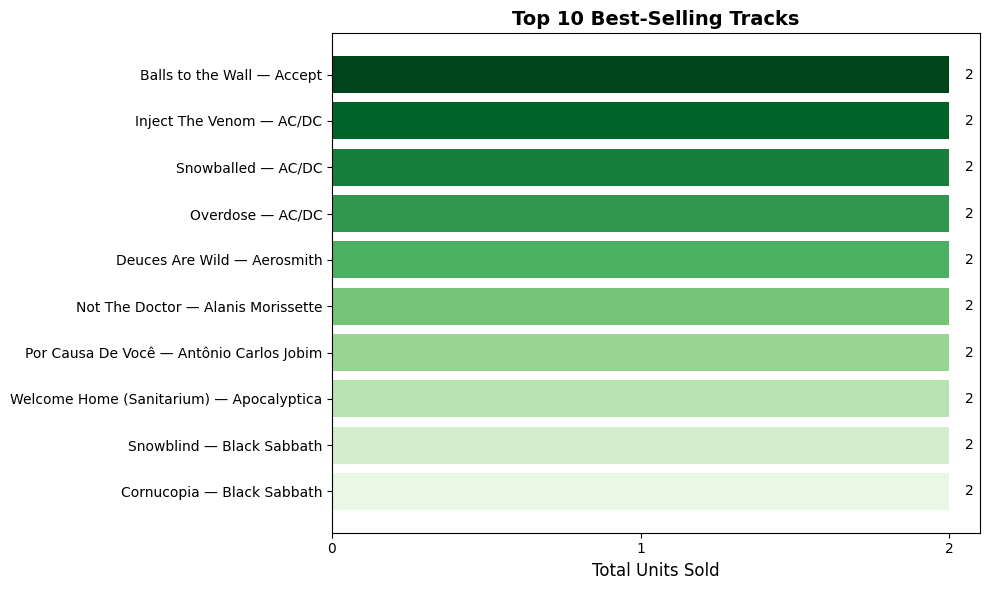

Chart saved as top_tracks.png


In [27]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    df_top_tracks["Track"] + " — " + df_top_tracks["Artist"],
    df_top_tracks["TotalSold"],
    color=plt.cm.Greens_r([i / 10 for i in range(10)])
)

ax.invert_yaxis()
ax.set_xlabel("Total Units Sold", fontsize=12)
ax.set_title("Top 10 Best-Selling Tracks", fontsize=14, fontweight="bold")
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

for bar, val in zip(bars, df_top_tracks["TotalSold"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=10)

plt.tight_layout()
plt.savefig("top_tracks.png", dpi=150)
plt.show()
print("Chart saved as top_tracks.png")

In [19]:
query_revenue = """
SELECT
    c.Country,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS TotalRevenue
FROM InvoiceLine il
JOIN Invoice  i ON il.InvoiceId  = i.InvoiceId
JOIN Customer c ON i.CustomerId  = c.CustomerId
GROUP BY c.Country
ORDER BY TotalRevenue DESC
LIMIT 10;
"""

df_revenue = pd.read_sql_query(query_revenue, conn)
print("Top 10 Countries by Revenue:")
display(df_revenue)

Top 10 Countries by Revenue:


,Country,TotalRevenue
0,USA,523.06
1,Canada,303.96
2,France,195.10
3,Brazil,190.10
4,Germany,156.48
5,United Kingdom,112.86
6,Czech Republic,90.24
7,Portugal,77.24
8,India,75.26
9,Chile,46.62


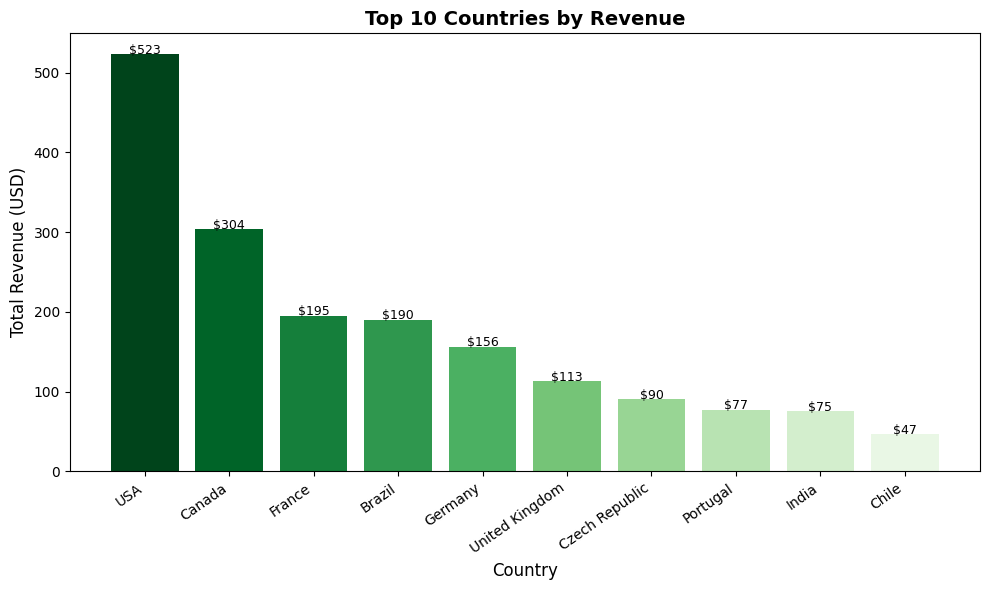

Chart saved as revenue_by_country.png


In [22]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = plt.cm.Greens_r([i / len(df_revenue) for i in range(len(df_revenue))])
bars = ax.bar(df_revenue["Country"], df_revenue["TotalRevenue"], color=colors)

ax.set_xlabel("Country", fontsize=12)
ax.set_ylabel("Total Revenue (USD)", fontsize=12)
ax.set_title("Top 10 Countries by Revenue", fontsize=14, fontweight="bold")
plt.xticks(rotation=35, ha="right")

for bar, val in zip(bars, df_revenue["TotalRevenue"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"${val:.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("revenue_by_country.png", dpi=150)
plt.show()
print("Chart saved as revenue_by_country.png")

In [23]:
query_employee = """
SELECT
    e.FirstName || ' ' || e.LastName   AS Employee,
    e.Title,
    ROUND(SUM(il.UnitPrice * il.Quantity), 2) AS TotalRevenue,
    COUNT(DISTINCT i.InvoiceId)         AS TotalInvoices
FROM Employee    e
JOIN Customer    c  ON c.SupportRepId = e.EmployeeId
JOIN Invoice     i  ON i.CustomerId   = c.CustomerId
JOIN InvoiceLine il ON il.InvoiceId   = i.InvoiceId
GROUP BY e.EmployeeId
ORDER BY TotalRevenue DESC;
"""

df_employee = pd.read_sql_query(query_employee, conn)
print("Sales Employee Performance:")
display(df_employee)

Sales Employee Performance:


,Employee,Title,TotalRevenue,TotalInvoices
0,Jane Peacock,Sales Support Agent,833.04,146
1,Margaret Park,Sales Support Agent,775.40,140
2,Steve Johnson,Sales Support Agent,720.16,126


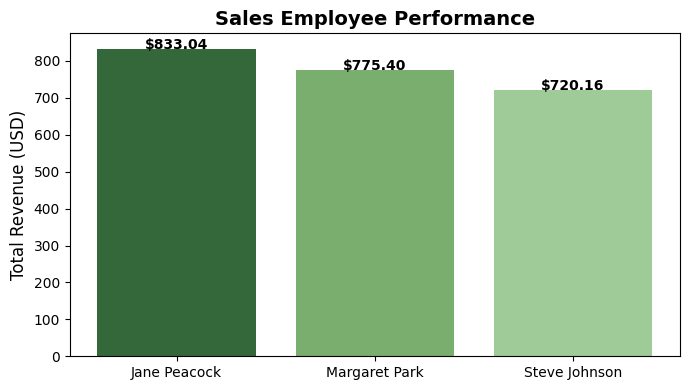

Chart saved as employee_performance.png


In [25]:
fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#346739", "#79AE6F", "#9FCB98"]
bars = ax.bar(df_employee["Employee"], df_employee["TotalRevenue"], color=colors)

ax.set_ylabel("Total Revenue (USD)", fontsize=12)
ax.set_title("Sales Employee Performance", fontsize=14, fontweight="bold")

for bar, val in zip(bars, df_employee["TotalRevenue"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"${val:.2f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("employee_performance.png", dpi=150)
plt.show()
print("Chart saved as employee_performance.png")

In [26]:
conn.close()
print("Database connection closed.")

Database connection closed.
